In [2]:
import pandas as pd
import numpy as np

from stable_baselines import A2C, PPO2, DDPG
from stable_baselines.common.vec_env import DummyVecEnv

from env.EnvMultipleStock_trade import StockEnvTrade
from env.EnvMultipleStock_validation import StockEnvValidation
from env.EnvMultipleStock_train import StockEnvTrain

def calculate_sharpe(df):
    df['daily_return'] = df['account_value'].pct_change(1)
    sharpe = (252**0.5) * df['daily_return'].mean() / df['daily_return'].std()
    return sharpe
def train_model(model_name, env_train, timesteps=50000):

    if model_name == "A2C":
        model = A2C("MlpPolicy", env_train, verbose=0)

    elif model_name == "PPO":
        model = PPO2("MlpPolicy", env_train, verbose=0)

    elif model_name == "DDPG":
        model = DDPG("MlpPolicy", env_train, verbose=0)

    else:
        raise ValueError("Invalid model")

    model.learn(total_timesteps=timesteps)
    return model
def validate_model(model, env_val):
    obs = env_val.reset()
    account_values = []

    for _ in range(len(env_val.envs[0].df.index.unique())):
        action, _ = model.predict(obs)
        obs, reward, done, info = env_val.step(action)

        account_values.append(env_val.envs[0].asset_memory[-1])

    df_val = pd.DataFrame(account_values, columns=["account_value"])
    sharpe = calculate_sharpe(df_val)

    return sharpe, df_val
def trade_model(model, env_trade):
    obs = env_trade.reset()
    account_values = []

    for _ in range(len(env_trade.envs[0].df.index.unique())):
        action, _ = model.predict(obs)
        obs, reward, done, info = env_trade.step(action)

        account_values.append(env_trade.envs[0].asset_memory[-1])

    df_trade = pd.DataFrame(account_values, columns=["account_value"])

    return df_trade
def run_ensemble_strategy(
    df,
    unique_trade_date,
    rebalance_window=63,
    validation_window=63
):

    print("Starting Ensemble Strategy...")

    df = df.sort_values(["datadate", "tic"])

    last_state = None
    ensemble_account_value = []

    for i in range(rebalance_window + validation_window, len(unique_trade_date), rebalance_window):

        print(f"\n===== Iteration {i} =====")

        # -------------------------
        # Define time windows
        # -------------------------
        train_start = 0
        train_end = i - validation_window
        val_start = train_end
        val_end = i
        trade_start = i
        trade_end = i + rebalance_window

        train_dates = unique_trade_date[train_start:train_end]
        val_dates = unique_trade_date[val_start:val_end]
        trade_dates = unique_trade_date[trade_start:trade_end]

        df_train = df[df.datadate.isin(train_dates)].copy()
        df_val = df[df.datadate.isin(val_dates)].copy()
        df_trade = df[df.datadate.isin(trade_dates)].copy()

        # 🔥 REQUIRED FOR ENVIRONMENT
        df_train.index = df_train.datadate.factorize()[0]
        df_val.index = df_val.datadate.factorize()[0]
        df_trade.index = df_trade.datadate.factorize()[0]
        
        #Sanity check
        print(df_train.loc[0].shape)

        # -------------------------
        # Create environments
        # -------------------------
        env_train = DummyVecEnv([lambda: StockEnvTrain(df_train)])
        env_val = DummyVecEnv([lambda: StockEnvValidation(df_val)])
        env_trade = DummyVecEnv([lambda: StockEnvTrade(df_trade)])

        # -------------------------
        # Train models
        # -------------------------
        model_a2c = train_model("A2C", env_train)
        model_ppo = train_model("PPO", env_train)
        model_ddpg = train_model("DDPG", env_train)

        # -------------------------
        # Validate models
        # -------------------------
        sharpe_a2c, _ = validate_model(model_a2c, env_val)
        sharpe_ppo, _ = validate_model(model_ppo, env_val)
        sharpe_ddpg, _ = validate_model(model_ddpg, env_val)

        print("Sharpe Ratios:")
        print("A2C:", sharpe_a2c)
        print("PPO:", sharpe_ppo)
        print("DDPG:", sharpe_ddpg)

        # -------------------------
        # Select best model
        # -------------------------
        sharpes = {
            "A2C": sharpe_a2c,
            "PPO": sharpe_ppo,
            "DDPG": sharpe_ddpg
        }

        best_model_name = max(sharpes, key=sharpes.get)
        print("Selected Model:", best_model_name)

        if best_model_name == "A2C":
            best_model = model_a2c
        elif best_model_name == "PPO":
            best_model = model_ppo
        else:
            best_model = model_ddpg

        # -------------------------
        # Trade
        # -------------------------
        df_trade_result = trade_model(best_model, env_trade)

        ensemble_account_value.append(df_trade_result)

    # -------------------------
    # Combine results
    # -------------------------
    df_ensemble = pd.concat(ensemble_account_value, ignore_index=True)

    return df_ensemble

In [4]:
df = pd.read_csv("new_done_data.csv")

df = df.sort_values(["datadate", "tic"])
df.index = df.datadate.factorize()[0]

unique_trade_date = df.datadate.unique()

result = run_ensemble_strategy(
    df=df,
    unique_trade_date=unique_trade_date,
    rebalance_window=63,
    validation_window=63
)

#result.to_csv("ensemble_portfolio_value_2.csv", index=False)

Starting Ensemble Strategy...

===== Iteration 126 =====
(30, 13)


Instructions for updating:
Use keras.layers.Dense instead.



Sharpe Ratios:
A2C: 0.06099920124775631
PPO: 0.06285720086000607
DDPG: 0.08353035758340853
Selected Model: DDPG
previous_total_asset:1000000
end_total_asset:998047.8771709152
total_reward:-1952.1228290847503
total_cost:  1985.5407295149253
total trades:  988
Sharpe:  -0.00601626547245022

===== Iteration 189 =====
(30, 13)
Sharpe Ratios:
A2C: 0.01627082624336141
PPO: -0.021545528116098
DDPG: -0.0004765862134172746
Selected Model: A2C
previous_total_asset:1000000
end_total_asset:1102341.9117032234
total_reward:102341.91170322336
total_cost:  4210.558947788649
total trades:  1351
Sharpe:  0.5346635068831869

===== Iteration 252 =====
(30, 13)
Sharpe Ratios:
A2C: 0.09423463177812913
PPO: 0.08774248127284874
DDPG: 0.12216720453490673
Selected Model: DDPG
previous_total_asset:1000000
end_total_asset:1018084.894906881
total_reward:18084.894906881033
total_cost:  3

Sharpe Ratios:
A2C: 0.17127522274327533
PPO: 0.14961125722099966
DDPG: 0.18322047219991658
Selected Model: DDPG
previous_total_asset:1000000
end_total_asset:1078097.112703266
total_reward:78097.11270326609
total_cost:  2256.4356212287034
total trades:  1126
Sharpe:  0.5230035323093164

===== Iteration 1449 =====
(30, 13)
Sharpe Ratios:
A2C: 0.07263018478514136
PPO: 0.04988225222233864
DDPG: 0.07878085640491012
Selected Model: DDPG
previous_total_asset:1000000
end_total_asset:897881.9836025152
total_reward:-102118.01639748481
total_cost:  4904.461021721219
total trades:  694
Sharpe:  -0.29957535945146324

===== Iteration 1512 =====
(30, 13)
Sharpe Ratios:
A2C: 0.184819577026895
PPO: 0.1349107190167554
DDPG: 0.2075018335451288
Selected Model: DDPG
previous_total_asset:1000000
end_total_asset:1085077.1708800052
total_reward:85077.17088000523
total_cost:  4436.964162157306
total trades:  1068
Sharpe:  0.3795007312207873

===== Iteration 1575 =====
(30, 13)
Sharpe Ratios:
A2C: 0.04378341809

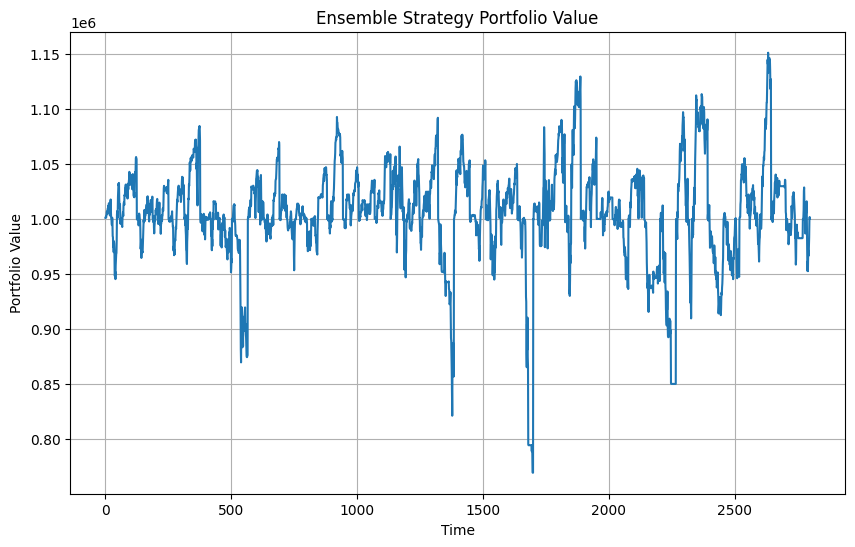

In [10]:
#Plot Ensemble Portfolio Value
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

df = pd.read_csv("ensemble_portfolio_value.csv")

plt.figure(figsize=(10,6))
plt.plot(df['account_value'])
plt.title("Ensemble Strategy Portfolio Value")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.grid()
plt.show()

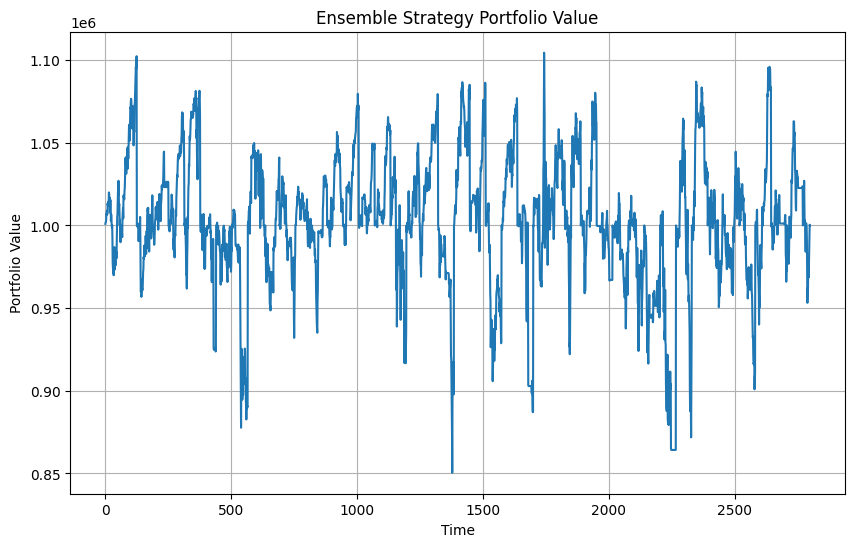

In [7]:
#Plot Ensemble Portfolio Value
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

df = pd.read_csv("ensemble_portfolio_value_2.csv")

plt.figure(figsize=(10,6))
plt.plot(df['account_value'])
plt.title("Ensemble Strategy Portfolio Value")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.grid()
plt.show()

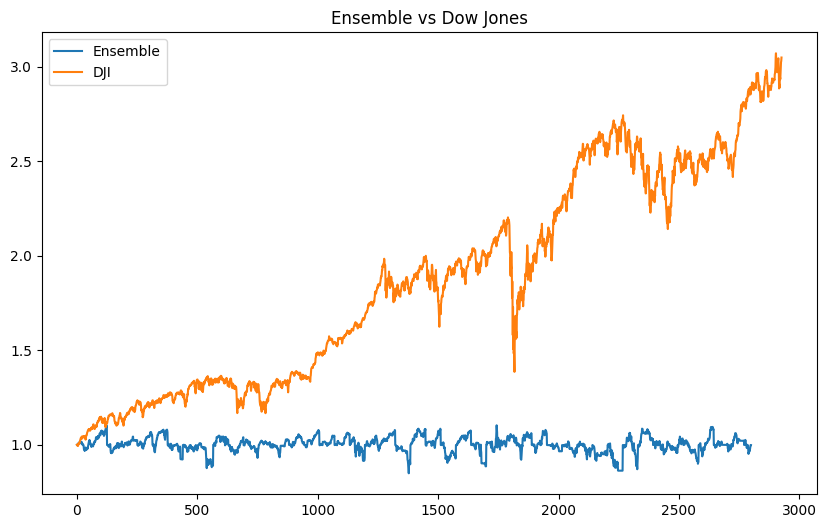

In [8]:
#Compare with baseline(DJI)
dji = pd.read_csv("data/cleaned_^DJI_20130102_20240819.csv")

plt.figure(figsize=(10,6))
plt.plot(df['account_value'] / df['account_value'].iloc[0], label="Ensemble")
plt.plot(dji['Close'] / dji['Close'].iloc[0], label="DJI")

plt.legend()
plt.title("Ensemble vs Dow Jones")
plt.show()

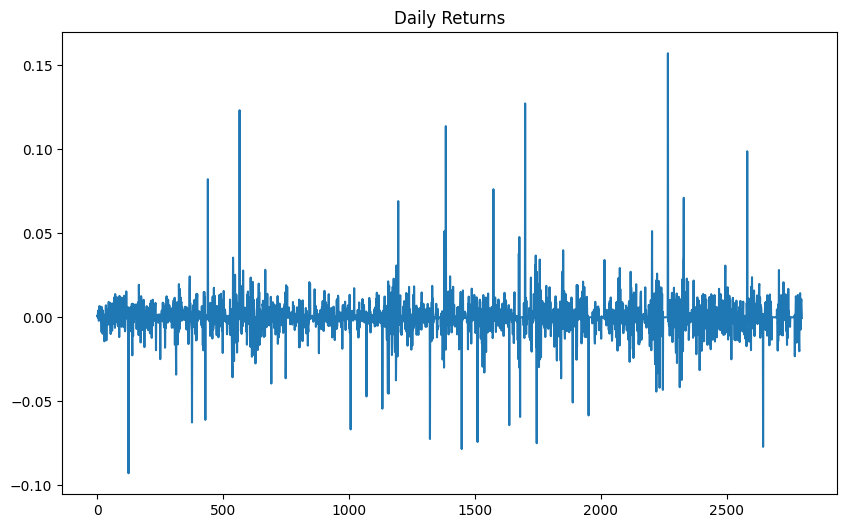

In [9]:
#Plot daily returns (Sharpe visualization)
df['returns'] = df['account_value'].pct_change()

plt.figure(figsize=(10,6))
plt.plot(df['returns'])
plt.title("Daily Returns")
plt.show()

In [10]:
#Compute final metrics
import numpy as np

returns = df['account_value'].pct_change().dropna()

sharpe = np.sqrt(252) * returns.mean() / returns.std()

total_return = df['account_value'].iloc[-1] / df['account_value'].iloc[0] - 1

print("Final Sharpe:", sharpe)
print("Total Return:", total_return)

Final Sharpe: 0.09135383943650223
Total Return: -0.0009466960043288397


In [11]:
#Compute FULL performance metrics (paper-level)
import numpy as np

returns = df['account_value'].pct_change().dropna()

# Annualized return
annual_return = (df['account_value'].iloc[-1] / df['account_value'].iloc[0])**(252/len(df)) - 1

# Volatility
volatility = returns.std() * np.sqrt(252)

# Sharpe
sharpe = np.sqrt(252) * returns.mean() / returns.std()

# Max Drawdown
cum = df['account_value']
peak = cum.cummax()
drawdown = (cum - peak) / peak
max_drawdown = drawdown.min()

print("Annual Return:", annual_return)
print("Volatility:", volatility)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_drawdown)

Annual Return: -8.523936328008741e-05
Volatility: 0.18546081796894318
Sharpe: 0.09135383943650223
Max Drawdown: -0.22850770167165355


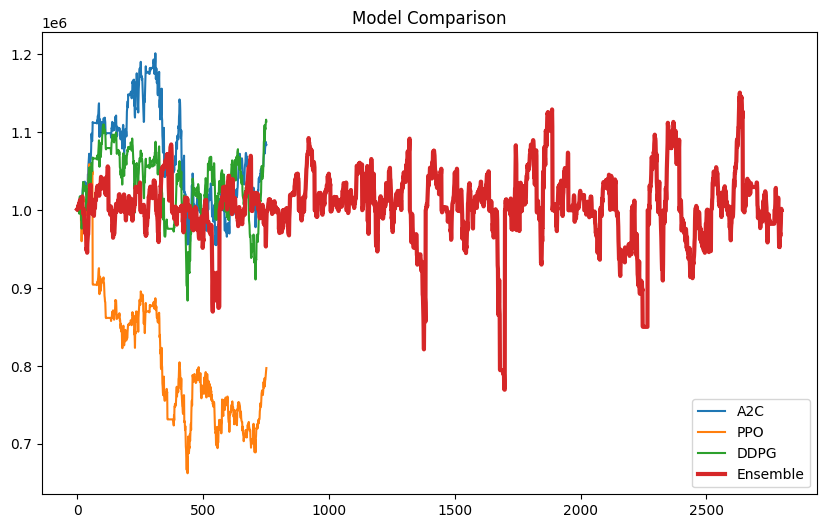

In [12]:
plt.figure(figsize=(10,6))

a2c = pd.read_csv("results/a2c_portfolio_value.csv")
ppo = pd.read_csv("results/ppo_portfolio_value.csv")
ddpg = pd.read_csv("results/ddpg_portfolio_value.csv")
ensemble = pd.read_csv("ensemble_portfolio_value.csv")
#print(ensemble.columns)

plt.plot(a2c, label="A2C")
plt.plot(ppo, label="PPO")
plt.plot(ddpg, label="DDPG")
plt.plot(ensemble, label="Ensemble", linewidth=3)

plt.legend()
plt.title("Model Comparison")
plt.show()

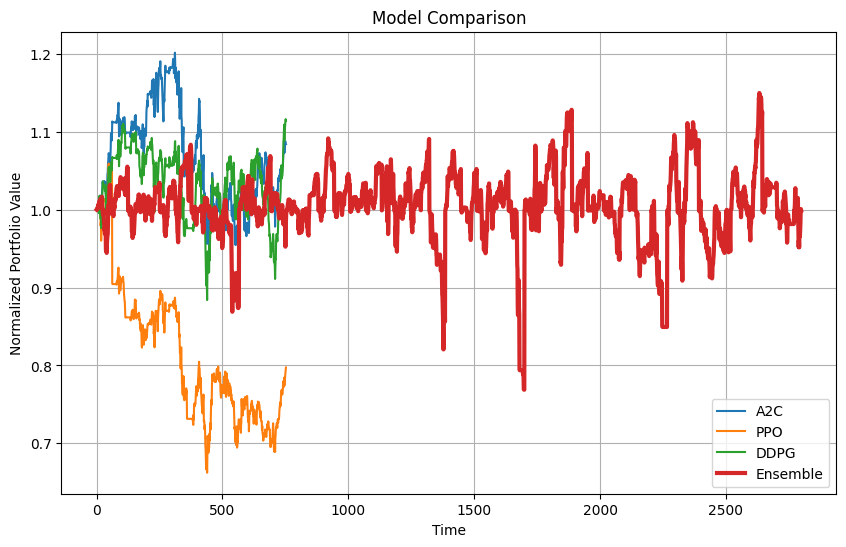

In [13]:
#clean version
import matplotlib.pyplot as plt

a2c = pd.read_csv("results/a2c_portfolio_value.csv")
ppo = pd.read_csv("results/ppo_portfolio_value.csv")
ddpg = pd.read_csv("results/ddpg_portfolio_value.csv")
ensemble = pd.read_csv("ensemble_portfolio_value.csv")

# normalize
ensemble_norm = ensemble['account_value'] / ensemble['account_value'].iloc[0]
a2c_norm = a2c['account_value'] / a2c['account_value'].iloc[0]
ppo_norm = ppo['account_value'] / ppo['account_value'].iloc[0]
ddpg_norm = ddpg['account_value'] / ddpg['account_value'].iloc[0]

plt.figure(figsize=(10,6))

plt.plot(a2c_norm, label="A2C")
plt.plot(ppo_norm, label="PPO")
plt.plot(ddpg_norm, label="DDPG")
plt.plot(ensemble_norm, label="Ensemble", linewidth=3)

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Time")
plt.ylabel("Normalized Portfolio Value")
plt.grid()

plt.show()

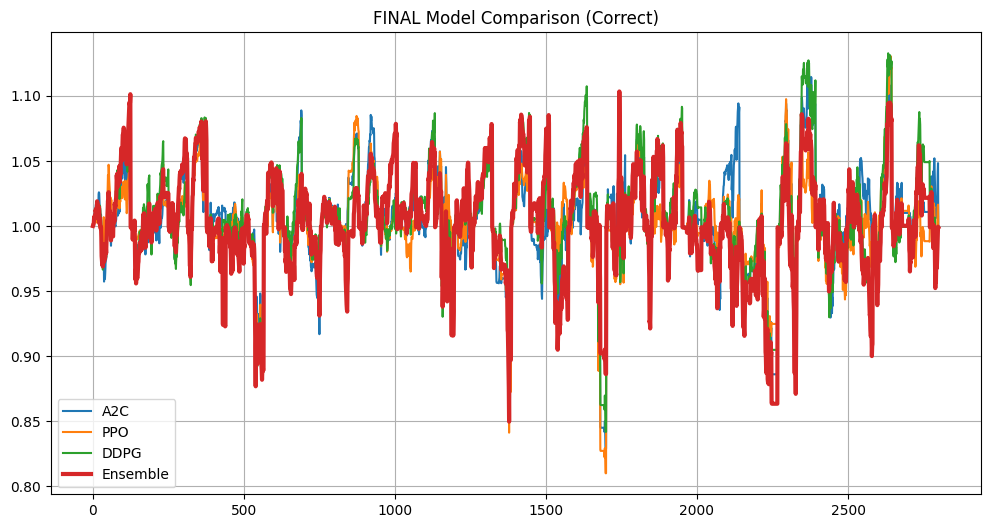

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

ensemble = pd.read_csv("ensemble_portfolio_value_2.csv")
a2c = pd.read_csv("a2c_full.csv")
ppo = pd.read_csv("ppo_full.csv")
ddpg = pd.read_csv("ddpg_full.csv")

# normalize
ensemble_norm = ensemble['account_value'] / ensemble['account_value'].iloc[0]
a2c_norm = a2c['account_value'] / a2c['account_value'].iloc[0]
ppo_norm = ppo['account_value'] / ppo['account_value'].iloc[0]
ddpg_norm = ddpg['account_value'] / ddpg['account_value'].iloc[0]

plt.figure(figsize=(12,6))

plt.plot(a2c_norm, label="A2C")
plt.plot(ppo_norm, label="PPO")
plt.plot(ddpg_norm, label="DDPG")
plt.plot(ensemble_norm, label="Ensemble", linewidth=3)

plt.legend()
plt.title("FINAL Model Comparison (Correct)")
plt.grid()

plt.show()